In [10]:
DATA_DIR = "../data"
MODELS_DIR = "../models"

In [11]:
import pandas as pd

df = pd.read_csv(f"{DATA_DIR}/preprocessed/train.csv")

display(df)

,elo_diff,winrate_10_diff,winrate_30_diff,experience_diff,rank_diff,h2h_winrate,team_1_wins
0,-0.142716,-0.049294,-0.066090,-0.110257,0.233918,-0.076338,1
1,-0.046395,2.760416,3.461053,-0.105192,0.047774,-0.076338,1
2,-0.142716,-0.049294,-0.066090,-0.110257,0.081619,-0.076338,1
3,-0.142716,-0.049294,-0.066090,-0.110257,-0.002992,-0.076338,0
4,-0.335358,-2.859004,-3.593233,-0.110257,-0.002992,-1.544189,0
...,...,...,...,...,...,...,...
41196,1.077886,1.917503,0.874482,1.054633,-0.138369,0.155428,1
41197,0.253357,0.512648,0.521767,1.647207,-0.646034,0.857750,1
41198,2.155184,1.917503,0.404196,3.429995,-0.222980,1.391514,1
41199,2.193711,2.198474,0.521767,3.429995,-0.222980,1.391514,1


In [12]:
target = "team_1_wins"

X = df.drop(target, axis=1)
y = df[target]

In [13]:
import os

import mlflow
from dotenv import load_dotenv

load_dotenv()

# os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("MLFLOW_S3_ACCESS_KEY", "")
# os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("MLFLOW_S3_SECRET_KEY", "")

# mlflow.set_tracking_uri(
#     os.getenv("MLFLOW_TRACKING_URI", "https://mlflow.internal.roxxas96.net")
# )
# experiment = mlflow.set_experiment(
#     os.getenv("MLFLOW_EXPERIMENT_NAME", "cs-go-match-predictor-local")
# )

# print(f"Experiment id: {experiment.experiment_id}")
# print(f"Experiment name: {experiment.name}")

True

In [14]:
import numpy as np
import tensorflow as tf
import tf2onnx
import onnx
from keras import callbacks, layers, metrics, models, optimizers
from mlflow.models import infer_signature
from sklearn.model_selection import train_test_split

learning_rate = 0.01
dense_1_units = 64
dense_2_units = 16
dropout = 0.3
batch_size = 128
epoch = 100
validation_split = 0.2
patience = 10

model = models.Sequential(
    [
        layers.Input(shape=(X.shape[1],)),
        layers.Dense(dense_1_units, activation="relu"),
        layers.Dropout(dropout),
        layers.BatchNormalization(),
        layers.Dense(dense_2_units, activation="relu"),
        layers.Dropout(dropout),
        layers.BatchNormalization(),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss="binary_crossentropy",
    metrics=["accuracy", metrics.AUC(name="auc")],
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=validation_split, random_state=42
)

train_ds = tf.data.Dataset.from_tensor_slices((X_train.values, y_train.values))
val_ds = tf.data.Dataset.from_tensor_slices((X_val.values, y_val.values))

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# with mlflow.start_run():
#     mlflow.log_params(
#         {
#             "learning_rate": learning_rate,
#             "dense_1_units": dense_1_units,
#             "dense_2_units": dense_2_units,
#             "dropout": dropout,
#             "batch_size": batch_size,
#             "epochs": epoch,
#             "validation_split": validation_split,
#             "patience": patience,
#             "optimizer": "Adam",
#             "loss": "binary_crossentropy",
#         }
#     )

#     train_dataset = mlflow.data.from_pandas(  # type: ignore
#         X_train.assign(target=y_train), targets="target"
#     )  # type: ignore
#     val_dataset = mlflow.data.from_pandas(X_val.assign(target=y_val), targets="target")  # type: ignore

#     mlflow.log_input(train_dataset, context="training")
#     mlflow.log_input(val_dataset, context="validation")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epoch,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_auc",
            patience=patience,
            restore_best_weights=True,
        )
    ],
)

    # for epoch_idx in range(len(history.history["loss"])):
    #     for metric_name, values in history.history.items():
    #         mlflow.log_metric(metric_name, values[epoch_idx], step=epoch_idx)

    # mlflow.log_metric("best_val_loss", np.min(history.history["val_loss"]))
    # mlflow.log_metric("best_val_auc", np.max(history.history["val_auc"]))

input_example = X_train.iloc[:5].astype(np.float32).to_numpy()
predictions = model.predict(input_example)

signature = infer_signature(input_example, predictions)

    # print(os.environ["AWS_ACCESS_KEY_ID"])

    # mlflow.tensorflow.log_model(  # type: ignore
    #     model,
    #     name="tf_model",  # replaces deprecated artifact_path
    #     signature=signature,
    #     input_example=input_example,
    #     tags={"runtime": "tensorflow"},
    # )

model.save(f"{MODELS_DIR}/model.keras")

spec = (tf.TensorSpec((None, len(X.columns)), tf.float32, name="input"),)

@tf.function(input_signature=spec)
def model_fn(x):
    return model(x)

onnx_path = f"{MODELS_DIR}/model/cs-go-match-predictor/1/model.onnx"

tf2onnx.convert.from_function(
    model_fn,
    opset=17,
    output_path=onnx_path,
    input_signature=spec,
)

onnx_model = onnx.load(onnx_path)

    # mlflow.onnx.log_model(  # type: ignore
    #     onnx_model, name="onnx_model", tags={"runtime": "onnx"}
    # )

Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step - accuracy: 0.7279 - auc: 0.7999 - loss: 0.5475 - val_accuracy: 0.7505 - val_auc: 0.8250 - val_loss: 0.5166
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.7407 - auc: 0.8117 - loss: 0.5314 - val_accuracy: 0.7515 - val_auc: 0.8264 - val_loss: 0.5098
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - accuracy: 0.7411 - auc: 0.8130 - loss: 0.5294 - val_accuracy: 0.7509 - val_auc: 0.8263 - val_loss: 0.5109
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - accuracy: 0.7424 - auc: 0.8143 - loss: 0.5276 - val_accuracy: 0.7527 - val_auc: 0.8270 - val_loss: 0.5086
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.7419 - auc: 0.8135 - loss: 0.5287 - val_accuracy: 0.7537 - val_auc: 0.8277 - val_loss: 0.5080
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.7428 - auc: 0.8147 - loss: 0.5269 - val_accuracy: 0.7532 - val_auc: 0.8273 - val_loss: 0.5084
Epoch 7/100
258/258 ━━

I0000 00:00:1779186384.556773  311683 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1779186384.556850  311683 single_machine.cc:376] Starting new session
I0000 00:00:1779186384.575407  311683 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1779186384.575435  311683 single_machine.cc:376] Starting new session


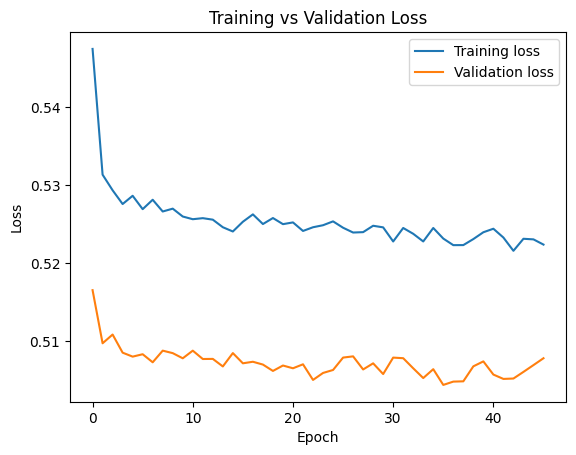

In [15]:
import matplotlib.pyplot as plt

loss = history.history["loss"]  # type: ignore
val_loss = history.history["val_loss"]  # type: ignore

plt.figure()
plt.plot(loss, label="Training loss")
plt.plot(val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [17]:
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.Series(y_train, name="team_1_wins")

train_ds = pd.concat([X_train_df, y_train_df], axis=1)

X_val_df = pd.DataFrame(X_val)
y_val_df = pd.Series(y_val, name="team_1_wins")

val_ds = pd.concat([X_val_df, y_val_df], axis=1)

train_ds.to_csv(f"{DATA_DIR}/train/train.csv", index=False)
val_ds.to_csv(f"{DATA_DIR}/train/val.csv", index=False)